<a href="https://colab.research.google.com/github/NajlaZuhir/Fake-News-Detection/blob/main/Fake_News_Detection_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detector Project in AI
https://www.projectpro.io/article/artificial-intelligence-project-ideas/461

### Step 1: Load the Data

In [ ]:
import pandas as pd

In [ ]:
# https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
df_fake = pd.read_csv("Fake.csv")
df_true = pd.read_csv("True.csv")

# ADD MORE DATASETS LIKE: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
# df_WELFake = pd.read_csv("WELFake_Dataset.csv") # Label (0 = fake and 1 = real).

In [ ]:
df_fake['label'] = 1
df_true['label'] = 0

In [ ]:
df_all = pd.concat([df_fake, df_true], ignore_index=True)

In [ ]:
cols = ['title', 'text', 'label']

In [ ]:
df_news = df_all[cols]

In [ ]:
'''Randomizing (or shuffling) the dataset after concatenation is a very good practice for ML models;
to Prevent Bias, Ensuring Representative Splits and Better Model Training'''

# Shuffle the DataFrame rows randomly
df_news = df_news.sample(frac=1, random_state=42).reset_index(drop=True)


# Display the head to see the shuffled data (labels should now be mixed)
display(df_news.head())

,title,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",0


In [ ]:
df_news.shape

(44898, 3)

In [ ]:
df_news["label"].value_counts()

,count
label,
1,23481
0,21417


### Step 2: Preprocessing


1) Delete unneeded columns
2) Check info, null, dublicates

In [ ]:
import re
from bs4 import BeautifulSoup, MarkupResemblesLocatorWarning
import html
import warnings

warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)

In [ ]:
# Summary of cols
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   44898 non-null  object
 1   text    44898 non-null  object
 2   label   44898 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


In [ ]:
# check null and dublicates
print("Duplicates: ",df_news.duplicated().sum())
print("Nulls:\n ",df_news.isnull().sum())

Duplicates:  5793
Nulls:
  title    0
text     0
label    0
dtype: int64


In [ ]:
df_news.drop_duplicates(inplace=True)
df_news.dropna(inplace=True)

3. text cleaning and normalization (basic cleaning)

In [ ]:

def clean_text(text):
    if text is None: return ""
    text = html.unescape(text)
    text = BeautifulSoup(text, "lxml").get_text(" ")
    text = re.sub(r"http\S+|www\.\S+|\S+@\S+\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [ ]:
# || token for separating segments.
df_news["title"] = df_news["title"].apply(clean_text)
df_news["text"] = df_news["text"].apply(clean_text)
df_news["content"] = (df_news["title"] + " || " + df_news["text"])
df_news = df_news[["content", "label"]]

In [ ]:

# Display the first few rows of the 'content' column
display(df_news.head())

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Lea...,1
4,Donald Trump heads for Scotland to reopen a go...,0


In [ ]:
df_news.shape

(39105, 2)

### Step 3: Using Models

In [ ]:
from sklearn.model_selection import train_test_split
import joblib
import pickle

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# DL
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.models import load_model


# TRANSFORMER
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import trange

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# 1) Load your dataframe (already cleaned/combined)
# df_news has columns: 'content', 'label' (0=Real, 1=Fake)
df = df_news.copy()

X = df["content"].astype(str).values
y = df["label"].astype(int).values


###### **Classical ML:** TF-IDF + Logistic Regression

Since classical ML models like Logistic Regression only accept numeric inputs, we first convert text into numeric vectors using TF-IDF.
- The TF-IDF + Logistic Regression pipeline is a common baseline approach for text classification.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) Build a simple pipeline
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000,
        stop_words="english"
    )),
    ("logreg", LogisticRegression(max_iter=200))
])

In [ ]:
pipe.fit(X_train, y_train)

print("Train acc:", pipe.score(X_train, y_train))
print("Test acc:", pipe.score(X_test, y_test))


Train acc: 0.9921685206495333
Test acc: 0.9879810765886715


In [ ]:
# 3) Save the model
joblib.dump(pipe, "tfidf+lr_fake_news.joblib")

['tfidf+lr_fake_news.joblib']

###### **Deep Learning:** LSTM
- stands for Long-Short Term Memory
- type of recurrent neural network (RNN) but is better than traditional recurrent neural networks in terms of memory
- with every other NN, LSTM can have multiple hidden layers and as it passes through every layer, the relevant information is kept and all the irrelevant information gets discarded in every single cell.

**Why LSTM?**
Tradition neural networks suffer from short-term memory. Also, a big drawback is the vanishing gradient problem. ( While backpropagation the gradient becomes so small that it tends to 0 and such a neuron is of no use in further processing.) LSTMs efficiently improves performance by memorizing the relevant information that is important and finds the pattern.

**Check:** https://www.analyticsvidhya.com/blog/2021/06/lstm-for-text-classification/

In [ ]:

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train samples:", len(X_train_text))
print("Test samples:", len(X_test_text))


Train samples: 31284
Test samples: 7821


In [ ]:
# -------- 3) Tokenize + pad --------

MAX_WORDS = 15000     # vocab size (smaller than Kaggle big ones)
MAX_LEN   = 300       # fixed max length (not 900+)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# use limited vocab via num_words, not full word_index
seq_train = tokenizer.texts_to_sequences(X_train_text)
seq_test  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(
    seq_train, maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test_pad = pad_sequences(
    seq_test, maxlen=MAX_LEN, padding="post", truncating="post"
)

voc_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("Effective vocab size:", voc_size)
print("Padded shapes:", X_train_pad.shape, X_test_pad.shape)

Effective vocab size: 15000
Padded shapes: (31284, 300) (7821, 300)


In [ ]:
# -------- 4) Build LSTM model (smaller than huge Kaggle one) --------

EMBED_DIM  = 64    # smaller than 128/300
LSTM_UNITS = 64    # smaller than 128/256

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=voc_size, output_dim=EMBED_DIM),
    LSTM(LSTM_UNITS, return_sequences=True),
    Dropout(0.3),
    LSTM(LSTM_UNITS),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")         # binary: 0=Real, 1=Fake
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 300, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,028,161 (3.92 MB)

 Trainable params: 1,028,161 (3.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -------- 5) Train with EarlyStopping --------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,           # not 120; early_stop will stop earlier if overfitting
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate final model
loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Final Test Accuracy: {acc:.4f}")

Epoch 1/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.5658 - loss: 0.6696 - val_accuracy: 0.7610 - val_loss: 0.5795
Epoch 2/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.6866 - loss: 0.5738 - val_accuracy: 0.9556 - val_loss: 0.1377
Epoch 3/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9678 - loss: 0.1255 - val_accuracy: 0.9826 - val_loss: 0.0716
Epoch 4/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9723 - loss: 0.1025 - val_accuracy: 0.7543 - val_loss: 0.4563
Epoch 5/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8359 - loss: 0.3807 - val_accuracy: 0.7888 - val_loss: 0.4586
Final Test Accuracy: 0.9826


In [ ]:
# 2) LSTM + tokenizer
model.save("lstm_fake_news.h5")
with open("tokenizer_lstm.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

###### **Transformer:** BERT (Pretrained)

from Hugging Face: https://huggingface.co/dhruvpal/fake-news-bert

In [1]:
model_name = "dhruvpal/fake-news-bert"

# Load once
bert_model = AutoModelForSequenceClassification.from_pretrained(model_name)
bert_tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# Use GPU if available
device = 0 if torch.cuda.is_available() else -1
pipe_bert  = pipeline(
    "text-classification",
    model=model_name,
    tokenizer=bert_tokenizer,
    device=device,
    truncation=True
)

Device set to use cuda:0


In [ ]:
texts = df_news["content"].tolist()
batch_size = 64  # adjust 32/64/128 depending on your RAM/GPU

pred_labels, pred_scores = [], []

for i in trange(0, len(texts), batch_size):   # trange() is from tqdm, adds a progress bar so you can track progress visually.
    batch = texts[i:i+batch_size]
    out = pipe_bert (batch, batch_size=batch_size, max_length=512)  # pipeline handles padding/truncation
    pred_labels.extend([int(o["label"].replace("LABEL_", "")) for o in out])
    pred_scores.extend([o["score"] for o in out])

df_news["pred_label"] = pred_labels
df_news["pred_score"] = pred_scores


100%|██████████| 612/612 [10:15<00:00,  1.01s/it]


In [ ]:
# figure out which index is FAKE
id2label = bert_model.config.id2label  # e.g. {0: 'REAL', 1: 'FAKE'}
fake_idx = None
for idx, lbl in id2label.items():
    if "FAKE" in lbl.upper():
        fake_idx = idx

if fake_idx is None:
    fake_idx = 1  # fallback: assume 1 = FAKE

print("BERT id2label:", id2label)
print("Using fake_idx =", fake_idx)

BERT id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
Using fake_idx = 1


Accuracy  : 0.9987
Precision : 0.9981
Recall    : 0.9991
F1-score  : 0.9986

Classification Report:
               precision    recall  f1-score   support

        Real       1.00      1.00      1.00     21197
        Fake       1.00      1.00      1.00     17908

    accuracy                           1.00     39105
   macro avg       1.00      1.00      1.00     39105
weighted avg       1.00      1.00      1.00     39105



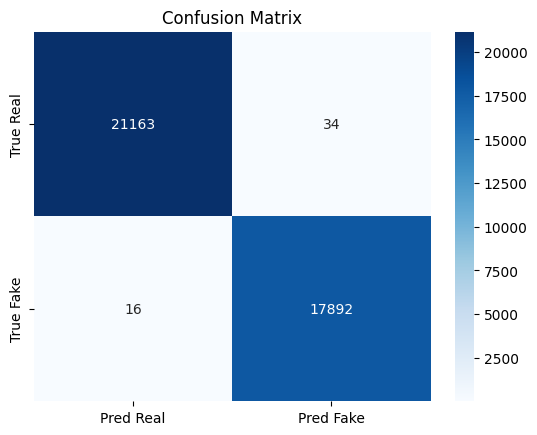

In [ ]:
# Evaluation------------------------

y_true = df_news["label"]
y_pred = df_news["pred_label"]

# Core metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred Real','Pred Fake'], yticklabels=['True Real','True Fake'])
plt.title("Confusion Matrix")
plt.show()


### Weighted soft voting ensemble (TF-IDF + LSTM)

In [ ]:

# --- load models ---
lr_model = joblib.load("tfidf+lr_fake_news.joblib")
lstm_model = load_model("lstm_fake_news.h5")
with open("tokenizer_lstm.pkl", "rb") as f:
    tokenizer = pickle.load(f)

MAX_LEN = 300   # same as used in training


In [ ]:
def prob_fake_tfidf(text: str) -> float:
    txt = clean_text(text)
    return pipe.predict_proba([txt])[0][1]      # probability of Fake


def prob_fake_lstm(text: str) -> float:
    txt = clean_text(text)
    seq = tokenizer.texts_to_sequences([txt])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    p = lstm_model.predict(pad, verbose=0)[0][0]
    return float(p)                              # probability of Fake





In [ ]:
def ensemble_predict(text: str,
                     w_tfidf: float = 0.4,
                     w_lstm: float = 0.6):

    p_fake_tfidf = prob_fake_tfidf(text)
    p_fake_lstm  = prob_fake_lstm(text)

    # Weighted probability of Fake
    p_fake = (w_tfidf * p_fake_tfidf + w_lstm * p_fake_lstm) / (w_tfidf + w_lstm)

    # Probability of Real
    p_real = 1 - p_fake

    # Final label
    label = 1 if p_fake >= 0.5 else 0

    return {
        "final_label": label,
        "prob_fake": p_fake,
        "prob_real": p_real,
        "models": {
            "tfidf": {
                "fake": p_fake_tfidf,
                "real": 1 - p_fake_tfidf
            },
            "lstm": {
                "fake": p_fake_lstm,
                "real": 1 - p_fake_lstm
            }
        }
    }

In [ ]:
# Real News (From GPT)

text_Real_1 = "The European Central Bank announced on Thursday that it will maintain current interest rates, citing steady economic recovery across member states. Officials stated that inflation pressures are easing and that monetary policy will remain focused on long-term stability."
text_Real_2 = "The Ministry of Education has confirmed that public schools will implement updated digital learning tools starting next academic year. The initiative aims to improve student engagement through modernized curricula and enhanced training for teachers."
text_Real_3 = "Japan’s Prime Minister held a joint press conference with U.S. officials today, emphasizing continued cooperation in regional security and economic development. Both sides reaffirmed their commitment to strengthening diplomatic ties."

In [ ]:
result = ensemble_predict(text_Real_3)

print("Final label:", "Fake" if result["final_label"] == 1 else "Real")
print("Final Fake probability:", result["prob_fake"])
print("Final Real probability:", result["prob_real"])

print("\nPer-model probabilities:")
print("TF-IDF → Fake:", result["models"]["tfidf"]["fake"],
      "Real:", result["models"]["tfidf"]["real"])

print("LSTM   → Fake:", result["models"]["lstm"]["fake"],
      "Real:", result["models"]["lstm"]["real"])


Final label: Real
Final Fake probability: 0.15747786335915812
Final Real probability: 0.8425221366408419

Per-model probabilities:
TF-IDF → Fake: 0.36990365163163563 Real: 0.6300963483683644
LSTM   → Fake: 0.015860671177506447 Real: 0.9841393288224936


In [ ]:
# Fake News (From GPT)

text_Fake_1 = "A new study claims that drinking two liters of Coca-Cola every day cures diabetes, according to researchers at a mysterious unlisted lab."
text_Fake_2 = "The government secretly approved a plan to replace all citizens’ ID cards with microchips implanted under the skin."
text_Fake_3 = "A time traveler from the year 2085 was allegedly arrested in Dubai after predicting the exact date of a future earthquake."

In [ ]:
result = ensemble_predict(text_Fake_1)

print("Final label:", "Fake" if result["final_label"] == 1 else "Real")
print("Final Fake probability:", result["prob_fake"])
print("Final Real probability:", result["prob_real"])

print("\nPer-model probabilities:")
print("TF-IDF → Fake:", result["models"]["tfidf"]["fake"],
      "Real:", result["models"]["tfidf"]["real"])

print("LSTM   → Fake:", result["models"]["lstm"]["fake"],
      "Real:", result["models"]["lstm"]["real"])


Final label: Fake
Final Fake probability: 0.9128930446571626
Final Real probability: 0.08710695534283741

Per-model probabilities:
TF-IDF → Fake: 0.7913472049103474 Real: 0.20865279508965262
LSTM   → Fake: 0.9939236044883728 Real: 0.006076395511627197


### *Some Key Learnings:*


**1) What is transformers**

**2) Types of transformers:**
| **Type**           | **Examples**              | **Use**                                               |
|---------------------|---------------------------|-------------------------------------------------------|
| **Encoder-only**    | BERT, RoBERTa             | Understanding text (classification, sentiment, fake news) |
| **Decoder-only**    | GPT, LLaMA, Mistral       | Generating text (chatbots, story writing)             |
| **Encoder–Decoder** | T5, BART                  | Text-to-text tasks (translation, summarization)       |


**3) How Pre-training and Fine-Tuning are Important For Optimal Performance**

**4) Why use pretrained Models from Hugging Face**

**5) ML vs DL vs Transformers**

**6) DL Frameworks: Pytorch vs Keras**

**7) Ensemble Learning Method vs AutoML**

### *What Next:*


- Benchmark Models For this Task
- look and test on various datasets → find domain shift
- Research Findings on text classification tasks
- Build simple Interface and connect the models maybe through FastAPI